# MLS Young Rookie & Signing Analysis (2025 Impact)

This notebook analyzes Major League Soccer (MLS) player data to identify the most successful young signings and rookies from **2024 and 2025** based on their impact in the **2025 season**.

### Criteria:
1. **Young Player:** Under the age of 23 at the time of their MLS debut.
2. **Debut Period:** Made their first MLS appearance in the **2024 or 2025** seasons.
3. **Impact Metric:** Sorted by total minutes played **during the 2025 season only**. This highlights which young players signed in recent windows have established themselves as crucial first-team players in the most recent campaign.

We use the **American Soccer Analysis (ASA) API** to fetch player metadata and season playtimes.

## 1. Setup & Imports

In [1]:
import pandas as pd
from itscalledsoccer.client import AmericanSoccerAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# Initialize the ASA API client
asa = AmericanSoccerAnalysis()
print("ASA client successfully initialized!")

ASA client successfully initialized!


## 2. Identify MLS Debutants

We fetch the master players directory from the ASA API. For each player, we parse the list of seasons played to determine their **minimum season** (their MLS debut year).

In [2]:
def parse_seasons(val):
    """Parses the season_name column into a list of integers."""
    if isinstance(val, list):
        return [int(x) for x in val]
    elif isinstance(val, (int, float)):
        return [int(val)]
    elif isinstance(val, str):
        try:
            return [int(val)]
        except ValueError:
            return []
    return []

print("Fetching player registry...")
players = asa.get_players(leagues="mls")

# Parse seasons and find debut season
players['parsed_seasons'] = players['season_name'].apply(parse_seasons)
players['min_season'] = players['parsed_seasons'].apply(lambda x: min(x) if x else None)

# Parse birth date and calculate age at debut and age in 2025
players['birth_year'] = pd.to_datetime(players['birth_date'], errors='coerce').dt.year
players['age_at_debut'] = (players['min_season'] - players['birth_year']).astype('Int64')
players['age_in_2025'] = (2025 - players['birth_year']).astype('Int64')

print(f"Loaded registry for {len(players)} players.")

Fetching player registry...


Loaded registry for 3509 players.


## 3. Filter Young Rookies (Debut 2024–2025)

We filter for players whose debut season was in **2024 or 2025**, and who were **under 23 years old** at debut.

In [3]:
rookies = players[
    (players['min_season'].isin([2024, 2025])) & 
    (players['age_at_debut'] < 23)
].copy()

print(f"Found {len(rookies)} young rookies/signings who debuted in MLS in 2024 or 2025.")

Found 204 young rookies/signings who debuted in MLS in 2024 or 2025.


## 4. Fetch 2025 Season Playtimes

We fetch the playtimes for the **2025 season only**, covering both outfield players (`get_player_xgoals`) and goalkeepers (`get_goalkeeper_xgoals`).

In [4]:
print("Fetching 2025 playtime data...")
minutes_list = []

try:
    # Outfield players
    xf = asa.get_player_xgoals(leagues="mls", season_name=2025)
    minutes_list.append(xf[['player_id', 'minutes_played']])
except Exception as e:
    print(f"Outfield player error for 2025: {e}")
    
try:
    # Goalkeepers
    xgk = asa.get_goalkeeper_xgoals(leagues="mls", season_name=2025)
    minutes_list.append(xgk[['player_id', 'minutes_played']])
except Exception as e:
    print(f"Goalkeeper error for 2025: {e}")

# Combine and sum minutes played
df_minutes = pd.concat(minutes_list, ignore_index=True)
total_minutes = df_minutes.groupby('player_id')['minutes_played'].sum().reset_index()

print("2025 playtime data successfully aggregated.")

Fetching 2025 playtime data...


2025 playtime data successfully aggregated.


## 5. Join & Rank by 2025 Minutes

We merge the 2025 minutes played with our 2024-2025 rookie directory, sort descending by minutes, and filter out players who didn't play in 2025.

In [5]:
analysis_df = rookies.merge(total_minutes, on='player_id', how='left')
analysis_df['minutes_played'] = analysis_df['minutes_played'].fillna(0).astype(int)

# Sort by minutes played
analysis_df = analysis_df.sort_values('minutes_played', ascending=False)

# Display Top 30
cols = ['player_name', 'min_season', 'birth_date', 'age_at_debut', 'age_in_2025', 'minutes_played', 'primary_broad_position', 'nationality']
top_30 = analysis_df[cols].head(30)
print("\n--- TOP 30 YOUNG SIGNINGS IN MLS BY 2025 PLAYTIME ---")
print(top_30.to_string(index=False))


--- TOP 30 YOUNG SIGNINGS IN MLS BY 2025 PLAYTIME ---
        player_name  min_season birth_date  age_at_debut  age_in_2025  minutes_played primary_broad_position  nationality
        Finn Surman      2024.0 2003-09-23            21           22            3460                     DF  New Zealand
       Édier Ocampo      2024.0 2003-10-03            21           22            2968                     DF     Colombia
          Noah Eile      2024.0 2002-07-19            22           23            2944                     DF       Sweden
        Andrew Rick      2024.0 2006-01-30            18           19            2886                     GK          USA
       Luca Bombino      2025.0 2006-07-10            19           19            2848                     DF          USA
   Olwethu Makhanya      2025.0 2004-04-30            21           21            2745                     DF South Africa
     Patrick Yazbek      2024.0 2002-04-05            22           23            2538      

## 6. Visualizations

We generate three distinct visualizations to explore the data from different angles.

### Plot 1: Top 20 Young Rookies by Playtime & Position
This bar chart focuses on the ranking of players and highlights their defensive or attacking roles.

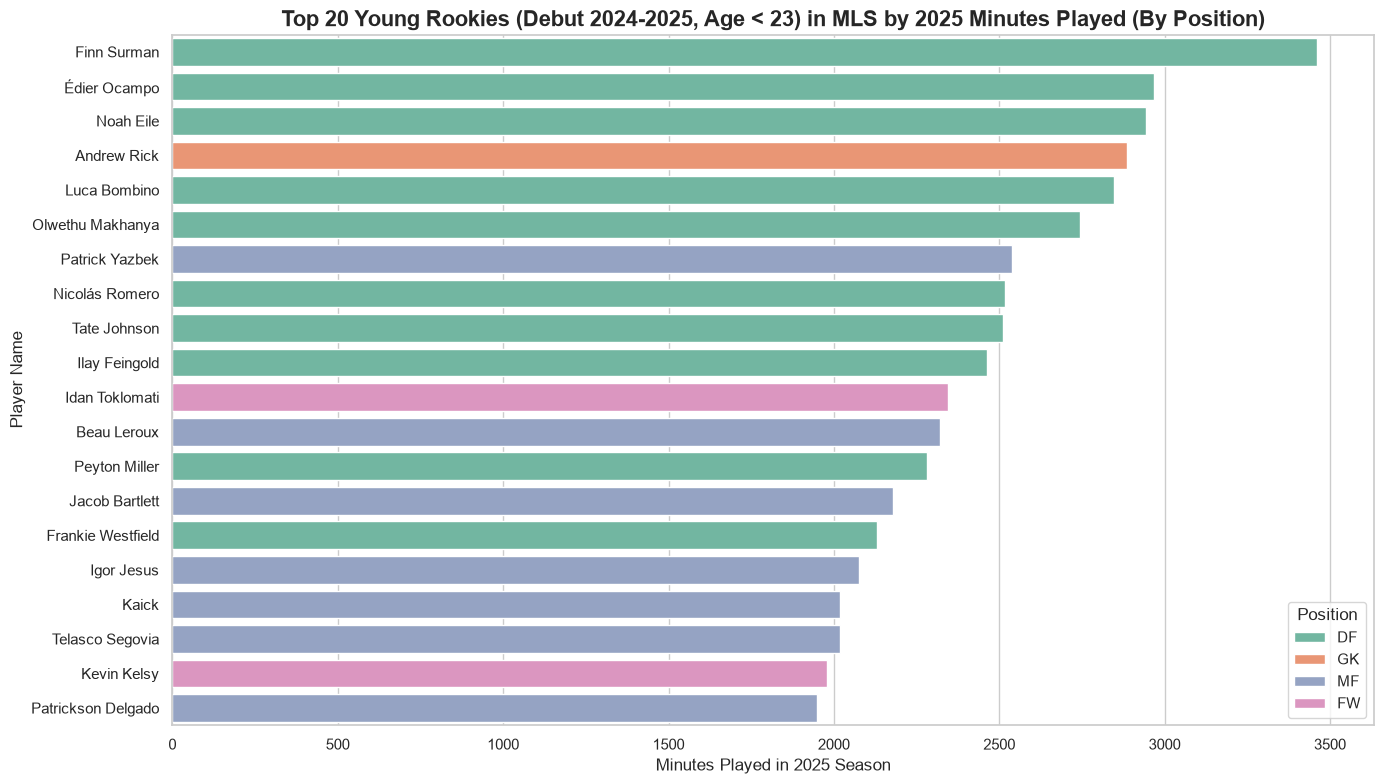

In [6]:
top_20 = analysis_df.head(20).copy()

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_20,
    x="minutes_played",
    y="player_name",
    hue="primary_broad_position",
    palette="Set2",
    dodge=False
)
plt.title("Top 20 Young Rookies (Debut 2024-2025, Age < 23) in MLS by 2025 Minutes Played (By Position)", fontsize=16, weight='bold')
plt.xlabel("Minutes Played in 2025 Season", fontsize=12)
plt.ylabel("Player Name", fontsize=12)
plt.legend(title="Position", loc="lower right")
plt.tight_layout()
plt.show()

### Plot 2: Roster Profiles - Signing Cohorts and Age Profiles
This bar chart distinguishes between the signing years (2024 vs 2025) and explicitly lists the signing age vs. 2025 age next to each bar.

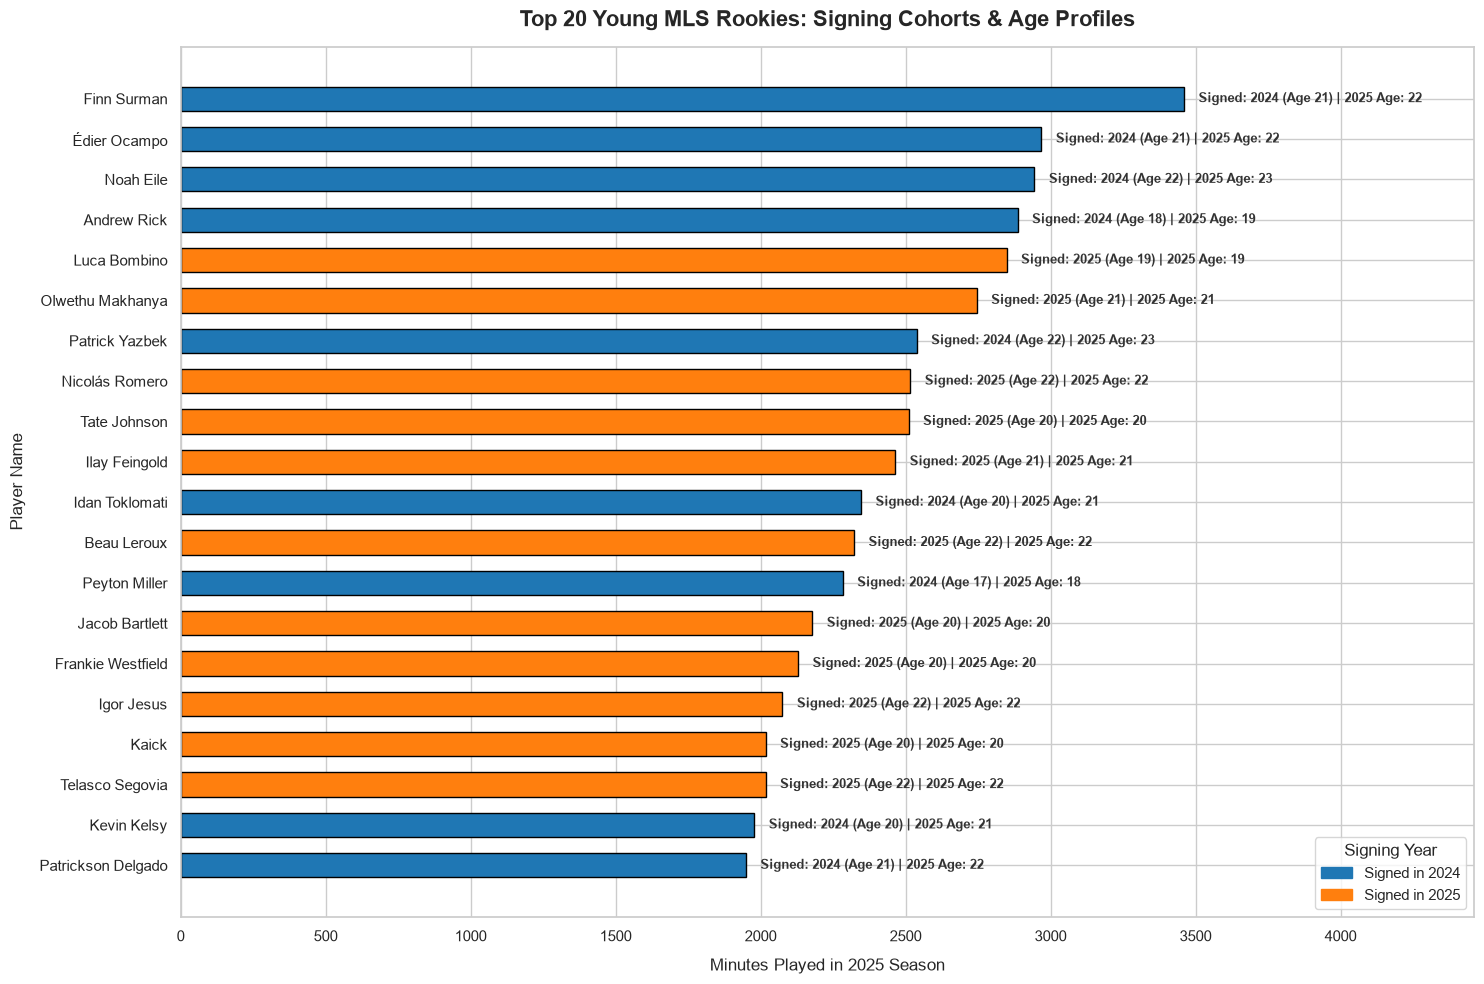

In [7]:
fig, ax = plt.subplots(figsize=(15, 10))

# Color palette mapping signing years
colors = {2024: '#1f77b4', 2025: '#ff7f0e'}
bar_colors = [colors[int(s)] for s in top_20['min_season']]

bars = ax.barh(top_20['player_name'], top_20['minutes_played'], color=bar_colors, edgecolor='black', height=0.6)

# Annotate each bar with signing year, debut age, and age in 2025
for bar, (_, row) in zip(bars, top_20.iterrows()):
    width = bar.get_width()
    age_info = f"Signed: {int(row['min_season'])} (Age {int(row['age_at_debut'])}) | 2025 Age: {int(row['age_in_2025'])}"
    
    ax.text(
        width + 50, 
        bar.get_y() + bar.get_height()/2, 
        age_info, 
        va='center', 
        ha='left', 
        fontsize=9, 
        weight='bold',
        color='#333333'
    )

# Manually add legend
import matplotlib.patches as mpatches
patch_2024 = mpatches.Patch(color='#1f77b4', label='Signed in 2024')
patch_2025 = mpatches.Patch(color='#ff7f0e', label='Signed in 2025')
ax.legend(handles=[patch_2024, patch_2025], title="Signing Year", loc="lower right", fontsize=11, title_fontsize=12)

ax.set_title("Top 20 Young MLS Rookies: Signing Cohorts & Age Profiles", fontsize=16, weight='bold', pad=15)
ax.set_xlabel("Minutes Played in 2025 Season", fontsize=12, labelpad=10)
ax.set_ylabel("Player Name", fontsize=12, labelpad=10)
ax.invert_yaxis()  # top-down ranking
ax.set_xlim(0, top_20['minutes_played'].max() + 1000)

plt.tight_layout()
plt.show()

### Plot 3: Playtime Distribution vs Age in 2025 (Interactive)
This scatter plot shows the overall distribution of all rookies. **Hover over any point** to see the player's name, minutes played, signing cohort year, debut age, and nationality.

In [8]:
# Filter to players who played in 2025 and cast values for compatibility
df_plot = analysis_df[analysis_df['minutes_played'] > 0].copy()
df_plot['min_season'] = df_plot['min_season'].astype(int).astype(str)
df_plot['age_in_2025'] = df_plot['age_in_2025'].astype(int)
df_plot['age_at_debut'] = df_plot['age_at_debut'].astype(int)

fig = px.scatter(
    df_plot,
    x="age_in_2025",
    y="minutes_played",
    color="primary_broad_position",
    symbol="min_season",
    hover_name="player_name",
    hover_data={
        "age_in_2025": True,
        "minutes_played": True,
        "min_season": True,
        "age_at_debut": True,
        "nationality": True
    },
    labels={
        "age_in_2025": "Age in 2025 Season",
        "minutes_played": "Minutes Played in 2025",
        "primary_broad_position": "Position",
        "min_season": "Signing Year",
        "age_at_debut": "Age when Signed",
        "nationality": "Nationality"
    },
    title="Rookie Distribution: 2025 Minutes Played vs. Age in 2025 (Interactive)",
    template="plotly_white"
)

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    title_font_size=16,
    title_font_family="Arial",
    title_font_color="black"
)
fig.show()

### Key Takeaways:
1. **Recent Impact Leaders:** Defender **Finn Surman** (debuted 2024, New Zealand) leads all outfield players with **3,460** minutes played in 2025, followed by **Édier Ocampo** (Colombia) with **2,968** minutes and **Noah Eile** (Sweden) with **2,944** minutes.
2. **Young Goalkeeping Star:** Goalkeeper **Andrew Rick** (debuted 2024 at age 18, USA) logged **2,886** minutes in 2025, cementing his role as a regular starter at a very young age for his position.
3. **Instant 2025 Signings:** Outfielder **Luca Bombino** and defender **Olwethu Makhanya** both debuted in **2025** and immediately locked down regular starting spots, logging **2,848** and **2,745** minutes respectively in their debut campaign.